Custom Model:
Intercept: 4.222151077447231
Slope: 2.9684675107010183
MSE: 0.9924386487246482

Sklearn Model:
Intercept: 4.222151077447232
Slope: 2.968467510701018


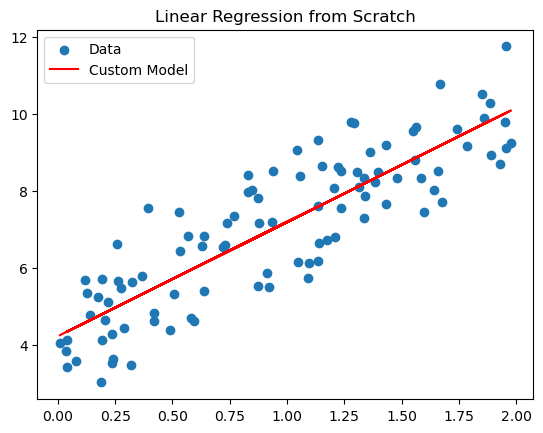

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# Normal Equation
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Custom Model:")
print("Intercept:", theta_best[0][0])
print("Slope:", theta_best[1][0])

# Predictions
y_pred = X_b.dot(theta_best)

# Error
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

# Compare with sklearn
model = LinearRegression()
model.fit(X, y)

print("\nSklearn Model:")
print("Intercept:", model.intercept_[0])
print("Slope:", model.coef_[0][0])

# Plot
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, "r-", label="Custom Model")
plt.legend()
plt.title("Linear Regression from Scratch")
plt.show()

Theta: [[-4.12635473]
 [ 4.45731562]]


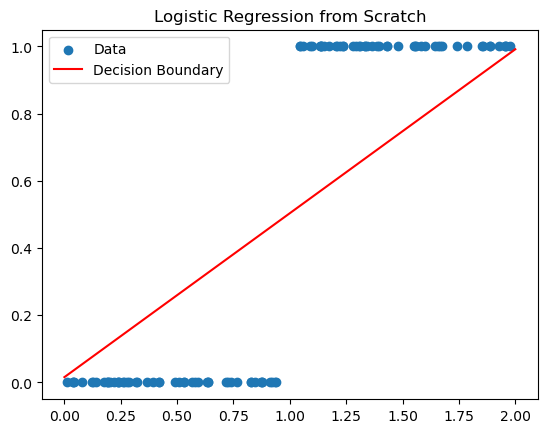

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = (X > 1).astype(int)  # 0 or 1 based on threshold

# Add bias
X_b = np.c_[np.ones((100, 1)), X]

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient Descent
theta = np.zeros((2, 1))
learning_rate = 0.1
iterations = 1000

for i in range(iterations):
    z = X_b.dot(theta)
    predictions = sigmoid(z)
    
    gradients = (1 / 100) * X_b.T.dot(predictions - y)
    theta = theta - learning_rate * gradients

print("Theta:", theta)

# Plot
plt.scatter(X, y, label="Data")

X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new]
y_prob = sigmoid(X_new_b.dot(theta))

plt.plot(X_new, y_prob, "r-", label="Decision Boundary")
plt.legend()
plt.title("Logistic Regression from Scratch")
plt.show()